In [3]:
'''
# Data Cleaning

## Objective

The objective of this notebook is to clean all raw datasets individually before merging them.

Cleaning includes:

- Handling Missing Values
- Removing Duplicates
- Checking Data Types
- Data Validation
- Saving Cleaned Data

Author: Vaishnavi Gavade
''' 

'\n# Data Cleaning\n\n## Objective\n\nThe objective of this notebook is to clean all raw datasets individually before merging them.\n\nCleaning includes:\n\n- Handling Missing Values\n- Removing Duplicates\n- Checking Data Types\n- Data Validation\n- Saving Cleaned Data\n\nAuthor: Vaishnavi Gavade\n'

In [4]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)
pd.set_option("display.width",1000)

In [5]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")

orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")

order_items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")

payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")

products = pd.read_csv("../data/raw/olist_products_dataset.csv")

reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

In [13]:
def data_quality_report(df, dataset_name):

    print("="*80)
    print(f"DATA QUALITY REPORT : {dataset_name.upper()}")
    print("="*80)

    print(f"\nShape : {df.shape}")

    print(f"\nRows : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

    print("\nData Types")
    print(df.dtypes)

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nMemory Usage")
    print(f"{df.memory_usage(deep=True).sum()/1024**2:.2f} MB")

In [14]:
data_quality_report(customers,"Customers")

DATA QUALITY REPORT : CUSTOMERS

Shape : (99441, 5)

Rows : 99441
Columns : 5

Data Types
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Missing Values
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Duplicate Rows
0

Unique Values
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

Memory Usage
26.59 MB


In [15]:
data_quality_report(orders,"Orders")

DATA QUALITY REPORT : ORDERS

Shape : (99441, 8)

Rows : 99441
Columns : 8

Data Types
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows
0

Unique Values
order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_ca

In [16]:
data_quality_report(order_items,"Order Items")

DATA QUALITY REPORT : ORDER ITEMS

Shape : (112650, 7)

Rows : 112650
Columns : 7

Data Types
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

Missing Values
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Duplicate Rows
0

Unique Values
order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

Memory Usage
35.99 MB


In [17]:
data_quality_report(products,"Products")

DATA QUALITY REPORT : PRODUCTS

Shape : (32951, 9)

Rows : 32951
Columns : 9

Data Types
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

Missing Values
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Duplicate Rows
0

Unique Values
product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product

In [18]:
data_quality_report(payments,"Payments")

DATA QUALITY REPORT : PAYMENTS

Shape : (103886, 5)

Rows : 103886
Columns : 5

Data Types
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

Missing Values
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Duplicate Rows
0

Unique Values
order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

Memory Usage
16.23 MB


In [19]:
data_quality_report(reviews,"Reviews")

DATA QUALITY REPORT : REVIEWS

Shape : (99224, 7)

Rows : 99224
Columns : 7

Data Types
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

Missing Values
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

Duplicate Rows
0

Unique Values
review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

Memory Usage
39.12 MB


In [20]:
def missing_values_summary(df, dataset_name):
    
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100

    summary = pd.DataFrame({
        "Missing Values": missing,
        "Percentage (%)": missing_percent.round(2)
    })

    summary = summary[summary["Missing Values"] > 0]

    print("=" * 80)
    print(f"MISSING VALUES SUMMARY : {dataset_name.upper()}")
    print("=" * 80)

    if summary.empty:
        print("✅ No Missing Values Found.")
    else:
        display(summary.sort_values(by="Percentage (%)", ascending=False))

In [21]:
missing_values_summary(customers, "Customers")

MISSING VALUES SUMMARY : CUSTOMERS
✅ No Missing Values Found.


In [22]:
missing_values_summary(orders, "Orders")

MISSING VALUES SUMMARY : ORDERS


,Missing Values,Percentage (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


In [23]:
missing_values_summary(order_items, "Order Items")

MISSING VALUES SUMMARY : ORDER ITEMS
✅ No Missing Values Found.


In [24]:
missing_values_summary(products, "Products")


MISSING VALUES SUMMARY : PRODUCTS


,Missing Values,Percentage (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


In [25]:
missing_values_summary(payments, "Payments")

MISSING VALUES SUMMARY : PAYMENTS
✅ No Missing Values Found.


In [26]:
missing_values_summary(reviews, "Reviews")

MISSING VALUES SUMMARY : REVIEWS


,Missing Values,Percentage (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70


In [29]:
import matplotlib.pyplot as plt

%matplotlib inline

In [30]:
def plot_missing_values(df, dataset_name):

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if len(missing) == 0:
        print(f"{dataset_name}: No Missing Values")
        return

    missing.sort_values().plot(
        kind="barh",
        figsize=(8,4)
    )

    plt.title(f"Missing Values - {dataset_name}")
    plt.xlabel("Count")
    plt.ylabel("Columns")

    plt.show()

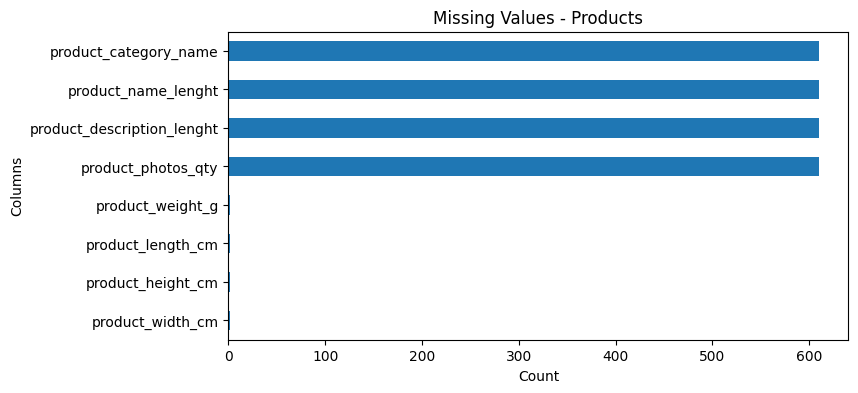

In [31]:
plot_missing_values(products, "Products")

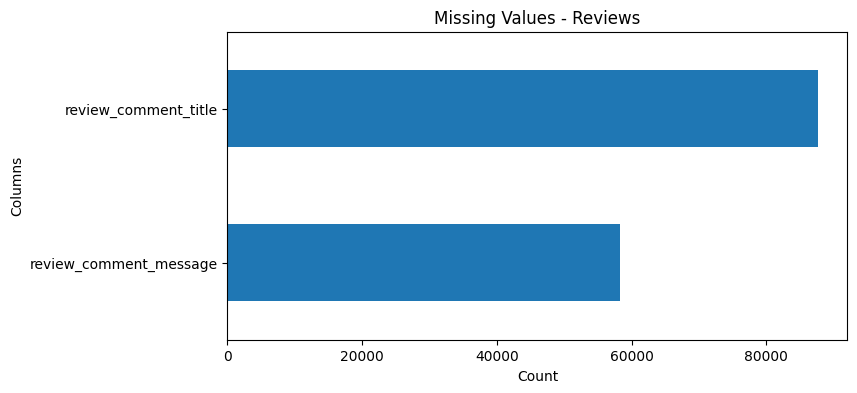

In [32]:
plot_missing_values(reviews, "Reviews")

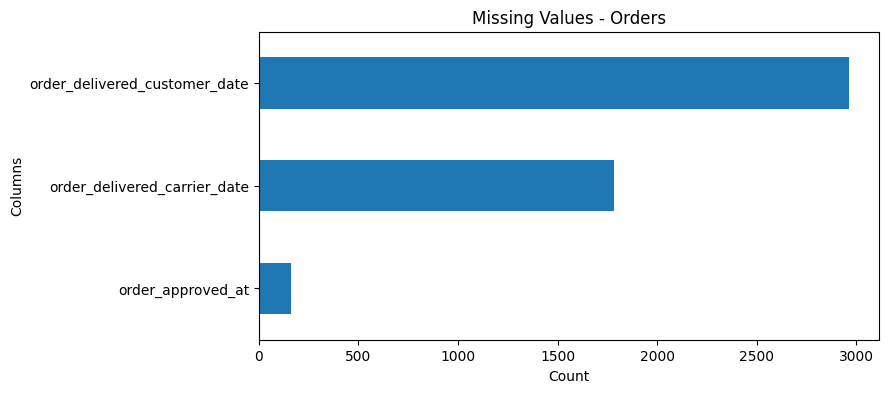

In [33]:
plot_missing_values(orders, "Orders")

In [34]:
missing_report = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Orders",
        "Order Items",
        "Products",
        "Payments",
        "Reviews"
    ],
    "Columns with Missing Values": [
        customers.isnull().any().sum(),
        orders.isnull().any().sum(),
        order_items.isnull().any().sum(),
        products.isnull().any().sum(),
        payments.isnull().any().sum(),
        reviews.isnull().any().sum()
    ],
    "Total Missing Values": [
        customers.isnull().sum().sum(),
        orders.isnull().sum().sum(),
        order_items.isnull().sum().sum(),
        products.isnull().sum().sum(),
        payments.isnull().sum().sum(),
        reviews.isnull().sum().sum()
    ]
})

missing_report

,Dataset,Columns with Missing Values,Total Missing Values
0,Customers,0,0
1,Orders,3,4908
2,Order Items,0,0
3,Products,8,2448
4,Payments,0,0
5,Reviews,2,145903


In [38]:
'''
## Datasets Requiring No Cleaning

After analyzing the data quality report:

- Customers dataset contains no missing values or duplicate rows.
- Order Items dataset contains no missing values or duplicate rows.
- Payments dataset contains no missing values or duplicate rows.

Therefore, no cleaning operations are required for these datasets.
'''

'\n## Datasets Requiring No Cleaning\n\nAfter analyzing the data quality report:\n\n- Customers dataset contains no missing values or duplicate rows.\n- Order Items dataset contains no missing values or duplicate rows.\n- Payments dataset contains no missing values or duplicate rows.\n\nTherefore, no cleaning operations are required for these datasets.\n'

In [43]:
print("="*90)
print("ORDERS DATASET CLEANING")
print("="*90)

ORDERS DATASET CLEANING


In [44]:
print("\nMissing Values\n")

orders.isnull().sum()


Missing Values



order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [45]:
orders[
    orders.isnull().any(axis=1)
].head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
162,36530871a5e80138db53bcfd8a104d90,4dafe3c841d2d6cc8a8b6d25b35704b9,shipped,2017-05-09 11:48:37,2017-05-11 11:45:14,2017-05-11 13:21:47,NaN,2017-06-08 00:00:00
231,4d630f57194f5aba1a3d12ce23e71cd9,6d491c9fe2f04f6e2af6ec033cd8907c,shipped,2017-11-17 19:53:21,2017-11-18 19:50:31,2017-11-22 17:28:34,NaN,2017-12-13 00:00:00
266,8e24261a7e58791d10cb1bf9da94df5c,64a254d30eed42cd0e6c36dddb88adf0,unavailable,2017-11-16 15:09:28,2017-11-16 15:26:57,NaN,NaN,2017-12-05 00:00:00
299,3b4ad687e7e5190db827e1ae5a8989dd,1a87b8517b7d31373b50396eb15cb445,shipped,2018-06-28 12:52:15,2018-06-28 13:11:09,2018-07-04 15:20:00,NaN,2018-08-03 00:00:00
305,b68d69564a79dea4776afa33d1d2fcab,de1e5517fb50896bbdcff5814fb31802,shipped,2018-02-28 08:57:03,2018-02-28 10:40:35,2018-03-05 16:10:13,NaN,2018-03-23 00:00:00


In [46]:
print("="*90)
print("Cleaning Decision")
print("="*90)

print("""
✔ Keep Missing Values

Reason:
Delivery dates are naturally missing for cancelled or unavailable orders.
Removing or filling these values would distort the business process.
""")

Cleaning Decision

✔ Keep Missing Values

Reason:
Delivery dates are naturally missing for cancelled or unavailable orders.
Removing or filling these values would distort the business process.



In [47]:
print("="*90)
print("Verification")
print("="*90)

orders.isnull().sum()

Verification


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [48]:
print("="*90)
print("CHECKING DUPLICATE ORDERS")
print("="*90)

print("Duplicate Rows :", orders.duplicated().sum())

CHECKING DUPLICATE ORDERS
Duplicate Rows : 0


In [49]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [50]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [51]:
orders[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [52]:
print("="*90)
print("ORDER STATUS")
print("="*90)

orders["order_status"].value_counts()

ORDER STATUS


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [53]:
invalid_dates = orders[
    orders["order_delivered_customer_date"] <
    orders["order_purchase_timestamp"]
]

print("Invalid Records :", len(invalid_dates))

Invalid Records : 0


In [54]:
print("="*90)
print("FINAL VERIFICATION - ORDERS DATASET")
print("="*90)

print("Shape :", orders.shape)

print("\nMissing Values")
print(orders.isnull().sum())

print("\nDuplicate Rows")
print(orders.duplicated().sum())

print("\nData Types")
print(orders.dtypes)

FINAL VERIFICATION - ORDERS DATASET
Shape : (99441, 8)

Missing Values
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Duplicate Rows
0

Data Types
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [55]:
print("=" * 90)
print("PRODUCTS DATASET CLEANING")
print("=" * 90)

PRODUCTS DATASET CLEANING


In [56]:
print("=" * 90)
print("CHECKING MISSING VALUES")
print("=" * 90)

products.isnull().sum()

CHECKING MISSING VALUES


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [57]:
print("=" * 90)
print("MISSING VALUE PERCENTAGE")
print("=" * 90)

missing_percentage = (
    products.isnull().sum() / len(products) * 100
).round(2)

missing_percentage

MISSING VALUE PERCENTAGE


product_id                    0.00
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
dtype: float64

In [58]:
print("=" * 90)
print("INSPECTING MISSING RECORDS")
print("=" * 90)

products[
    products.isnull().any(axis=1)
].head(10)

INSPECTING MISSING RECORDS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
244,e10758160da97891c2fdcbc35f0f031d,NaN,NaN,NaN,NaN,2200.0,16.0,2.0,11.0
294,39e3b9b12cd0bf8ee681bbc1c130feb5,NaN,NaN,NaN,NaN,300.0,16.0,7.0,11.0
299,794de06c32a626a5692ff50e4985d36f,NaN,NaN,NaN,NaN,300.0,18.0,8.0,14.0
347,7af3e2da474486a3519b0cba9dea8ad9,NaN,NaN,NaN,NaN,200.0,22.0,14.0,14.0
428,629beb8e7317703dcc5f35b5463fd20e,NaN,NaN,NaN,NaN,1400.0,25.0,25.0,25.0


In [61]:
print("=" * 90)
print("MISSING VALUES SUMMARY")
print("=" * 90)

products.isnull().sum()[products.isnull().sum() > 0]

MISSING VALUES SUMMARY


product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [63]:
print("=" * 90)
print("FILLING NUMERIC MISSING VALUES")
print("=" * 90)

numeric_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in numeric_columns:
    products[col] = products[col].fillna(products[col].median())

print("Numeric missing values filled successfully.")

FILLING NUMERIC MISSING VALUES
Numeric missing values filled successfully.


In [64]:
print("=" * 90)
print("FILLING CATEGORICAL MISSING VALUES")
print("=" * 90)

products["product_category_name"] = products["product_category_name"].fillna("Unknown")

print("Categorical missing values filled successfully.")

FILLING CATEGORICAL MISSING VALUES
Categorical missing values filled successfully.


In [68]:
print("=" * 90)
print("OPTIMIZING DATA TYPES")
print("=" * 90)

integer_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

for col in integer_columns:
    products[col] = products[col].astype(int)

print("Integer columns converted successfully.")

OPTIMIZING DATA TYPES
Integer columns converted successfully.


In [69]:
products.dtypes

product_id                     object
product_category_name          object
product_name_lenght             int64
product_description_lenght      int64
product_photos_qty              int64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [70]:
print("=" * 90)
print("VERIFYING CLEANED DATA")
print("=" * 90)

products.isnull().sum()

VERIFYING CLEANED DATA


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [71]:
print("=" * 90)
print("CHECKING DUPLICATE RECORDS")
print("=" * 90)

print("Duplicate Rows:", products.duplicated().sum())

CHECKING DUPLICATE RECORDS
Duplicate Rows: 0


In [72]:
print("=" * 90)
print("FINAL VERIFICATION - PRODUCTS DATASET")
print("=" * 90)

print("Shape:", products.shape)

print("\nMissing Values:")
print(products.isnull().sum())

print("\nDuplicate Rows:")
print(products.duplicated().sum())

print("\nData Types:")
print(products.dtypes)

FINAL VERIFICATION - PRODUCTS DATASET
Shape: (32951, 9)

Missing Values:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Duplicate Rows:
0

Data Types:
product_id                     object
product_category_name          object
product_name_lenght             int64
product_description_lenght      int64
product_photos_qty              int64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object


In [73]:
print("=" * 90)
print("REVIEWS DATASET CLEANING")
print("=" * 90)

REVIEWS DATASET CLEANING


In [74]:
print("=" * 90)
print("CHECKING MISSING VALUES")
print("=" * 90)

reviews.isnull().sum()

CHECKING MISSING VALUES


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [75]:
print("=" * 90)
print("MISSING VALUE PERCENTAGE")
print("=" * 90)

missing_percentage = (
    reviews.isnull().sum() / len(reviews) * 100
).round(2)

missing_percentage

MISSING VALUE PERCENTAGE


review_id                   0.00
order_id                    0.00
review_score                0.00
review_comment_title       88.34
review_comment_message     58.70
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64

In [76]:
print("=" * 90)
print("INSPECTING MISSING RECORDS")
print("=" * 90)

reviews[
    reviews.isnull().any(axis=1)
].head(10)

INSPECTING MISSING RECORDS


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
10,c9cfd2d5ab5911836ababae136c3a10c,cdf9aa68e72324eeb25c7de974696ee2,5,NaN,NaN,2017-12-23 00:00:00,2017-12-26 14:36:03


In [77]:
print("=" * 90)
print("MISSING VALUES SUMMARY")
print("=" * 90)

reviews.isnull().sum()[reviews.isnull().sum() > 0]

MISSING VALUES SUMMARY


review_comment_title      87656
review_comment_message    58247
dtype: int64

In [78]:
print("=" * 90)
print("FILLING MISSING REVIEW TITLES")
print("=" * 90)

reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Title")

print("Review titles filled successfully.")

FILLING MISSING REVIEW TITLES
Review titles filled successfully.


In [79]:
print("=" * 90)
print("FILLING MISSING REVIEW COMMENTS")
print("=" * 90)

reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")

print("Review comments filled successfully.")

FILLING MISSING REVIEW COMMENTS
Review comments filled successfully.


In [80]:
print("=" * 90)
print("VERIFYING CLEANED DATA")
print("=" * 90)

reviews.isnull().sum()

VERIFYING CLEANED DATA


review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [81]:
print("=" * 90)
print("CHECKING DUPLICATE RECORDS")
print("=" * 90)

print("Duplicate Rows:", reviews.duplicated().sum())

CHECKING DUPLICATE RECORDS
Duplicate Rows: 0


In [82]:
print("=" * 90)
print("FINAL VERIFICATION - REVIEWS DATASET")
print("=" * 90)

print("Shape:", reviews.shape)

print("\nMissing Values:")
print(reviews.isnull().sum())

print("\nDuplicate Rows:")
print(reviews.duplicated().sum())

print("\nData Types:")
print(reviews.dtypes)

FINAL VERIFICATION - REVIEWS DATASET
Shape: (99224, 7)

Missing Values:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Duplicate Rows:
0

Data Types:
review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object


In [83]:
customers.to_csv("../data/processed/customers_cleaned.csv", index=False)

orders.to_csv("../data/processed/orders_cleaned.csv", index=False)

order_items.to_csv("../data/processed/order_items_cleaned.csv", index=False)

products.to_csv("../data/processed/products_cleaned.csv", index=False)

payments.to_csv("../data/processed/payments_cleaned.csv", index=False)

reviews.to_csv("../data/processed/reviews_cleaned.csv", index=False)

print("All cleaned datasets saved successfully!")

All cleaned datasets saved successfully!


In [1]:
import os

print(os.getcwd())

C:\Users\HP\Ecommerce_Analytics_Project\notebooks


In [2]:
import os

os.startfile(os.getcwd())